# PCA Visualization with Confidence Ellipses

This notebook generates and analyzes a 2D rotated Gaussian point cloud using PCA.
It demonstrates how PCA recovers the principal directions and variance of the data,
visualizing them along with 1-, 2-, and 3-standard deviation confidence ellipses.

The data is generated by:
1. Creating points with specified variances along principal axes
2. Rotating the points by π/3 radians
3. Translating to a specified center

## Generating Synthetic Data

We create a 2D Gaussian point cloud with different standard deviations along each axis,
then rotate it by π/3 and shift it to a non-zero centre. This simulates correlated data
where the true principal directions are known.

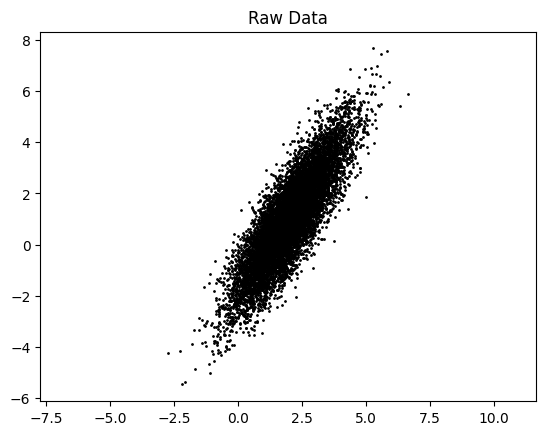

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Generate synthetic data
xC = np.array([2, 1])      # Center point for the cloud
sig = np.array([2, 0.5])   # Standard deviations along principal axes
theta = np.pi/3            # Rotation angle
R = np.array([[np.cos(theta), -np.sin(theta)],    # 2D rotation matrix
             [np.sin(theta), np.cos(theta)]])

# Create rotated and translated point cloud
nPoints = 10000
X = R @ np.diag(sig) @ np.random.randn(2,nPoints) + np.diag(xC) @ np.ones((2,nPoints))

# Plot raw data
plt.scatter(X[0,:], X[1,:], color='k', s=1)
plt.title('Raw Data')
plt.axis('equal')
plt.show()

## Centering the Data

PCA operates on zero-mean data. We subtract the sample mean (centroid) from every point
so the cloud is centered at the origin.

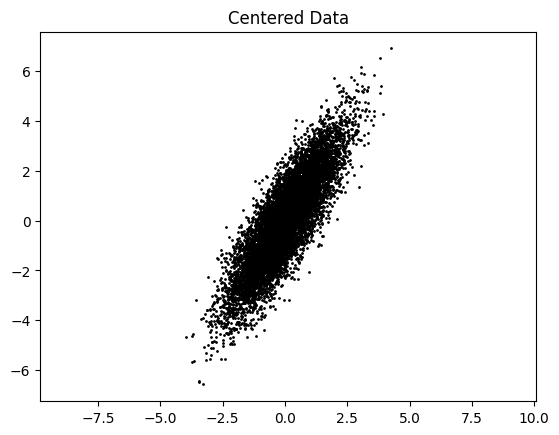

In [8]:
# Center the data
Xavg = np.mean(X, axis=1)  # Compute centroid
B = X - Xavg.reshape(-1,1)  # Center the data

plt.scatter(B[0,:],B[1,:], color='k', s=1)
plt.title('Centered Data')
plt.axis('equal')
plt.show()

## Normalising the Data

Dividing by √N makes the singular values of the matrix equal to the standard deviations
of the data along each principal axis, which simplifies interpretation.

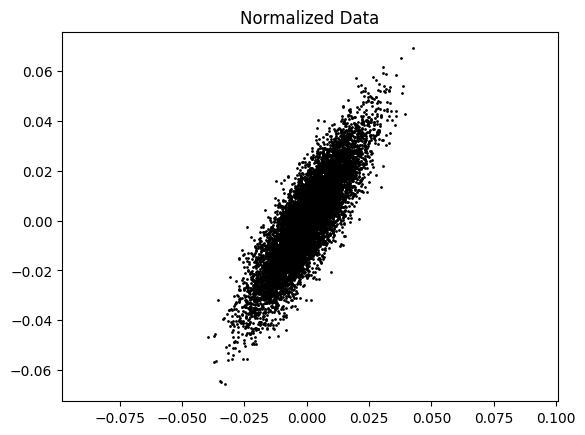

In [9]:
# Normalize by sqrt(nPoints) to get standard deviations as singular values
B = B / np.sqrt(nPoints)
plt.scatter(B[0,:],B[1,:], color='k', s=1)
plt.title('Normalized Data')
plt.axis('equal')
plt.show()

## Singular Value Decomposition (PCA)

SVD of the normalised data matrix gives us:
- **U** — the principal directions (should closely match the rotation matrix R)
- **S** — the singular values, which equal the standard deviations along each direction

In [10]:
# Perform SVD for PCA
U, S, VT = np.linalg.svd(B, full_matrices=False)

print(R) # Notice how they are very similar 
print(U)
print(S) # Sigma values recovered from the S matix

[[ 0.5       -0.8660254]
 [ 0.8660254  0.5      ]]
[[-0.50120154 -0.86533058]
 [-0.86533058  0.50120154]]
[2.00895365 0.49896324]


## Confidence Ellipses and Principal Components

Using U and S we can draw ellipses at 1, 2, and 3 standard deviations from the mean,
and plot arrows along each principal direction scaled by the corresponding standard deviation.

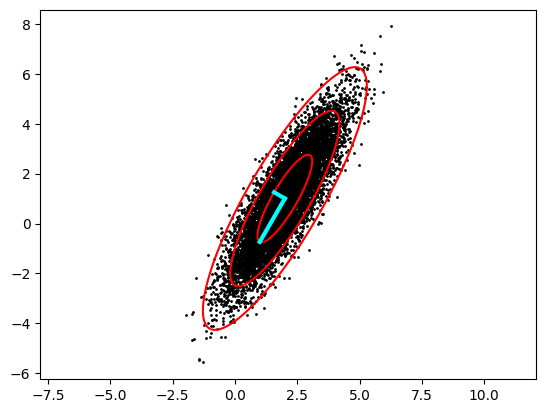

In [11]:
# Generate points for confidence ellipses
theta = 2 * np.pi * np.arange(0, 1, 0.01)
Xstd = U @ np.diag(S) @ np.array([np.cos(theta), np.sin(theta)])

# Plot confidence ellipses at 1, 2, and 3 standard deviations
plt.plot(Xavg[0] + Xstd[0,:], Xavg[1] + Xstd[1,:], '-', color='r')
plt.plot(Xavg[0] + 2*Xstd[0,:], Xavg[1] + 2*Xstd[1,:], '-', color='r')
plt.plot(Xavg[0] + 3*Xstd[0,:], Xavg[1] + 3*Xstd[1,:], '-', color='r')

# Plot principal components
plt.plot(np.array([Xavg[0], Xavg[0]+U[0,0]*S[0]]),
        np.array([Xavg[1], Xavg[1]+U[1,0]*S[0]]), '-', color='cyan', linewidth=3)
plt.plot(np.array([Xavg[0], Xavg[0]+U[0,1]*S[1]]),
        np.array([Xavg[1], Xavg[1]+U[1,1]*S[1]]), '-', color='cyan', linewidth=3)
plt.scatter(X[0], X[1], color='k', s=1)
plt.axis('equal')
plt.show()